In [1]:
import pandas as pd
import pysam
import os
import json

# assemblies

In [2]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [3]:
df = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DavidPorubsky/AZFc_ColorBLock_Clusters_12162025.csv")

## Read in MSA

In [4]:
from __future__ import annotations

from pathlib import Path
from typing import Union, List, Dict
import pandas as pd


def msa_fasta_to_df(
    fasta_path: Union[str, Path],
    *,
    long: bool = False,
    keep_gaps: bool = True,
    fill_value: str = "-",
) -> pd.DataFrame:
    """
    Read a multi-sequence alignment FASTA and convert to a pandas DataFrame.

    Parameters
    ----------
    fasta_path : str | Path
        Path to an MSA FASTA file.
    long : bool
        If False (default): return wide matrix with index=sequence IDs and columns=positions (1..L).
        If True: return long/tidy table with columns: id, pos, base.
    keep_gaps : bool
        If True, keep '-' gap characters as-is. If False, convert '-' to NaN.
    fill_value : str
        When sequences are different lengths, pad shorter ones to max length with this value.
        For an MSA this should rarely be needed, but it makes the function robust.

    Returns
    -------
    pd.DataFrame
    """
    fasta_path = Path(fasta_path)
    if not fasta_path.exists():
        raise FileNotFoundError(f"FASTA not found: {fasta_path}")

    seqs: Dict[str, str] = {}
    cur_id = None
    cur_chunks: List[str] = []

    def _commit():
        nonlocal cur_id, cur_chunks
        if cur_id is None:
            return
        seq = "".join(cur_chunks).strip()
        if not seq:
            raise ValueError(f"Empty sequence for record '{cur_id}' in {fasta_path}")
        if cur_id in seqs:
            raise ValueError(f"Duplicate FASTA header/id '{cur_id}' in {fasta_path}")
        seqs[cur_id] = seq
        cur_id, cur_chunks = None, []

    with fasta_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                _commit()
                cur_id = line[1:].split()[0]
                cur_chunks = []
            else:
                if cur_id is None:
                    raise ValueError("FASTA parse error: sequence line before any header ('>').")
                cur_chunks.append(line)

    _commit()

    if not seqs:
        raise ValueError(f"No sequences found in {fasta_path}")

    max_len = max(len(s) for s in seqs.values())
    ids = list(seqs.keys())
    mat = []
    for i in ids:
        s = seqs[i]
        if len(s) < max_len:
            s = s + (fill_value * (max_len - len(s)))
        elif len(s) > max_len:
            s = s[:max_len]
        mat.append(list(s))

    wide = pd.DataFrame(mat, index=ids, columns=pd.RangeIndex(1, max_len + 1, name="pos"))
    wide.index.name = "id"

    if not keep_gaps:
        wide = wide.replace("-", pd.NA)

    if not long:
        return wide
    long_df = (
        wide.reset_index()
            .melt(id_vars="id", var_name="pos", value_name="base")
            .sort_values(["id", "pos"], kind="stable")
            .reset_index(drop=True)
    )
    if not keep_gaps:
        long_df.loc[long_df["base"] == "-", "base"] = pd.NA
    return long_df


In [5]:
import re
from typing import List, Tuple

def pair_front_back_different_samples(row_names: List[str]) -> List[Tuple[str, str]]:
    """
    Return (front_row, back_row) pairs where:
      - front/back suffix is determined by the final '_' token (case-insensitive)
      - sample name is everything before ':' (e.g., 'NA19331' from 'NA19331_chrY:...')
      - the samples are different (e.g., NA19331 front can pair with HG01074 back)
    """
    front_rows = []  
    back_rows  = []  

    suffix_re = re.compile(r"_([^_]+)$")  

    for r in row_names:
        if ":" not in r:
            continue
        sample = r.split(":", 1)[0].strip()

        m = suffix_re.search(r)
        if not m:
            continue
        suffix = m.group(1).strip().lower()

        if suffix == "front":
            front_rows.append((sample, r))
        elif suffix == "back":
            back_rows.append((sample, r))

    pairs: List[Tuple[str, str]] = []
    for s_front, r_front in front_rows:
        for s_back, r_back in back_rows:
            if s_front != s_back:  
                pairs.append((r_front, r_back))

    return pairs

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_front_back_quadrants(df,
                             sample_col="Sample",
                             x_col="Coordinate",
                             y_col="Hit",
                             hue_col="MatchType",
                             point_size=5,
                             alpha=0.6,
                             vlines=None, outFile=None):
    """
    vlines (Option B):
      - dict keyed by (SampleName, Side) -> list of x positions
      - OR dict keyed by SampleName -> list of x positions (applies to both sides)
      - If not a dict, treated as a list applied to all panels
    """

    d = df.copy()

    d["SampleName"] = d[sample_col].str.split(":").str[0]
    d["Side"] = d[sample_col].str.extract(r"_(Front|Back)$", expand=False)
    bounds = d[sample_col].str.extract(r":(\d+)-(\d+)_", expand=True)
    d["Xmin"] = pd.to_numeric(bounds[0], errors="coerce")
    d["Xmax"] = pd.to_numeric(bounds[1], errors="coerce")
    d[x_col] = pd.to_numeric(d[x_col], errors="coerce")
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")

    d = d.dropna(subset=["SampleName", "Side", "Xmin", "Xmax", x_col, y_col, hue_col])

    agg = (
        d.groupby(["SampleName", "Side", x_col, hue_col], as_index=False)[y_col]
         .sum()
    )

    limits = (
        d.groupby(["SampleName", "Side"], as_index=False)
         .agg(xmin=("Xmin", "min"), xmax=("Xmax", "max"))
    )

    samples = sorted(agg["SampleName"].unique())
    sides = ["Front", "Back"]
    matchtypes = sorted(agg[hue_col].unique())

    fig, axes = plt.subplots(
        len(samples), 2,
        figsize=(12, max(3.0, 3.0 * len(samples))),
        sharey=True,
        squeeze=False,
        constrained_layout=True
    )

    for i, sname in enumerate(samples):
        for j, side in enumerate(sides):
            ax = axes[i, j]

            sub = agg[(agg["SampleName"] == sname) & (agg["Side"] == side)]
            lim = limits[(limits["SampleName"] == sname) & (limits["Side"] == side)]

            if sub.empty or lim.empty:
                ax.set_title(f"{sname} | {side} (no data)")
                ax.set_axis_off()
                continue

            xmin, xmax = int(lim["xmin"].iloc[0])-1000, int(lim["xmax"].iloc[0])+1000

            for mt in matchtypes:
                ssub = sub[sub[hue_col] == mt]
                if ssub.empty:
                    continue
                ax.scatter(
                    ssub[x_col].astype(int).values,
                    ssub[y_col].values,
                    s=point_size,
                    alpha=alpha,
                    label=str(mt),
                    c=str(mt) 
                )

            if isinstance(vlines, dict):
                xs = vlines.get((sname, side), vlines.get(sname, []))
            else:
                xs = vlines or []

            for x in xs:
                ax.axvline(int(x), linestyle="--", linewidth=1, alpha=0.7, color='red')

            ax.set_xlim(xmin, xmax)
            ax.set_xlabel("Coordinate")
            if j == 0:
                ax.set_ylabel("Count")
            ax.set_title(f"{sname} | {side}")

    # legend
    #handles, labels = axes[0, 0].get_legend_handles_labels()
    #if handles:
    #    fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 6), frameon=False)

    if outFile:
        plt.savefig(outFile, dpi=300)
    plt.show()

HG01255_HG01167_T2TvsGRCh38_JUSTACHECK.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_22243/1212307245.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


2546: SAME
6549: SAME
7460: SAME
9016: SAME
11323: SAME
14465: SAME
14623: SAME
16714: SAME
17905: SAME
18062: SAME
18737: SAME
19611: SAME
21045: SAME
26500: SAME
27166: SAME
28106: SAME
28906: SAME
28929: SAME
29501: SAME
29541: SAME
30999: SAME
31150: SAME
31575: SAME
31641: SAME
31771: SAME
32166: SAME
33215: SAME
33504: SAME
34111: SAME
34982: SAME
35858: SAME
37009: SAME
37162: SAME
37618: SAME
38034: SAME
38975: SAME
38985: SAME
39848: SAME
40809: SAME
40940: SAME
44686: SAME
48198: SAME
48532: SAME
50219: SAME
58197: SAME
58203: SAME
66539: SAME
68308: SAME
68390: SAME
71249: SAME
78194: FRONT-BACK2
92614: SAME
100057: SAME
101756: SAME
102719: SAME
109031: SAME
110413: SAME
111245: SAME
111289: SAME
111319: SAME
117567: FRONT-BACK2
125871: SAME
127258: SAME
128207: SAME
128616: SAME
132800: SAME
134643: SAME
150153: SAME
152270: SAME
153109: SAME
157948: SAME
160017: SAME
160903: FRONT-BACK2
169504: SAME
171132: SAME
186993: SAME
196597: SAME
197112: SAME
203813: SAME
204120: 

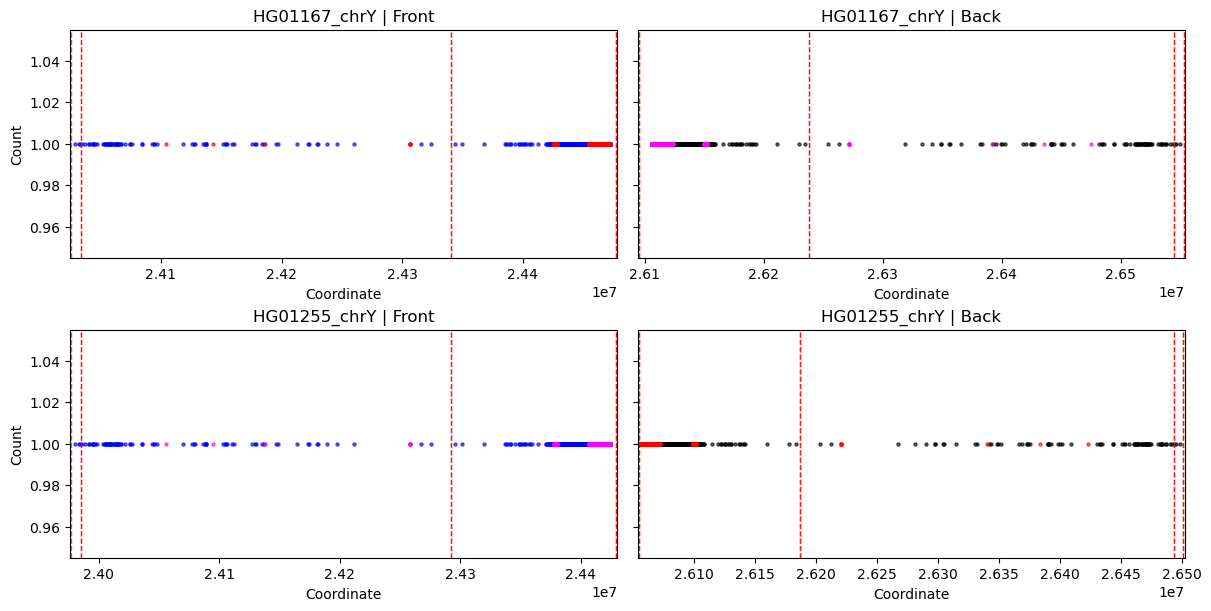

In [7]:
import numpy as np
import collections

directory='/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/alignments/'
for fastaFile in os.listdir(directory):
    if '.fasta' in fastaFile:
        print(fastaFile)
        outFilePath = '/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/alignments/T2TvsGRCh38_'+str(fastaFile.split(".fasta")[0])+".pdf"

        df_wide = msa_fasta_to_df(directory+fastaFile)
        
        coordinateDict = {r: {} for r in df_wide.index}
        for r in df_wide.index:
            rlow = str(r).lower()
            region = r.split(":", 1)[1]
            a, b = region.split("-", 1)
            start_bp = int(a)
            end_bp   = int(b.split("_", 1)[0])  
        
            if "_front" in rlow:
                coord = start_bp
                step = 1
            elif "_back" in rlow:
                coord = end_bp
                step = -1
            else:
                raise ValueError(f"Row missing _front/_back suffix: {r}")
        
            for c in df_wide.columns:
                if df_wide.at[r, c] == "-":
                    continue
                coordinateDict[r][c] = coord
                coord += step
        
        df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()
        interestingColumns=[]
        for column in df_wide2.columns:
            if len(set(df_wide2[column]))==1:
                continue
            else:
                interestingColumns.append(column)

        newDF = df_wide[interestingColumns].copy()

        pairs = pair_front_back_different_samples(list(newDF.index))

        newList=[]
        for column in newDF.columns:
            tempDict = collections.Counter(newDF[column])
            
            if len(tempDict)==2 and tempDict[list(tempDict.keys())[0]]==2:
                
                if newDF.at[pairs[0][0],column]==newDF.at[pairs[0][1],column]:
                    print(str(column)+": FRONT-BACK2")
                    newList.append([pairs[0][0], coordinateDict[pairs[0][0]][column], 1, 'magenta'])
                    newList.append([pairs[0][1], coordinateDict[pairs[0][1]][column], 1, 'magenta'])
                    newList.append([pairs[1][0], coordinateDict[pairs[1][0]][column], 1, 'red'])
                    newList.append([pairs[1][1], coordinateDict[pairs[1][1]][column], 1, 'red'])
                else:
                    print(str(column)+": SAME")
                    newList.append([pairs[0][0], coordinateDict[pairs[0][0]][column], 1, 'blue'])
                    newList.append([pairs[0][1], coordinateDict[pairs[0][1]][column], 1, 'black'])
                    newList.append([pairs[1][0], coordinateDict[pairs[1][0]][column], 1, 'blue'])
                    newList.append([pairs[1][1], coordinateDict[pairs[1][1]][column], 1, 'black'])
                    continue

        finalCountDF = pd.DataFrame(data=newList, columns=['Sample', 'Coordinate', 'Hit', 'MatchType'])


        vlines={}
        for sample in set(finalCountDF['Sample']):
            side = sample.split("_")[-1]
            contig = sample.split(":")[0]
            startcoord = int(sample.split(":")[1].split("-")[0])
            endcoord = int(sample.split(":")[1].split("-")[1].split("_")[0])
            
            df2 = df[(df['contig']==contig)].copy()
            goodRows=[]
            for row,start,end in zip(df2.index, df2['start'], df2['end']):
                if start < endcoord and end > startcoord:
                    goodRows.append(row)
            df3 = df2.loc[goodRows].copy()
            coords=[x+1 for x in df3['start']]
            for y in df3['end']:
                coords.append(y-1)
            vlines[(contig, side)]=sorted(coords)
            
        plot_front_back_quadrants(finalCountDF, vlines=vlines, outFile=outFilePath)